# 옷 개기

### 현재 연결 상태

In [1]:
from IPython.core.display import Markdown, HTML
display(Markdown("[현재 기기 연결 상태]"), display_id="device_state")
display(HTML(""), display_id="device_state_errors")
display(HTML(""), display_id="motor_server_state");


> ✅ 장비 초기화 완료

- **Follower**: ✅ **연결됨**
  - 왼팔: `/dev/lerobot/follower_1`
  - 오른팔: `/dev/lerobot/follower_2`
  - 전경 카메라: `/dev/lerobot/camera_0`
  - 왼팔 카메라: `/dev/lerobot/camera_1`
  - 오른팔 카메라: `/dev/lerobot/camera_2`
- **Leader**: ✅ **연결됨**
  - Left Arm: `/dev/lerobot/leader_1`
  - Right Arm: `/dev/lerobot/leader_2`
    

HBox()

## 기본 초기화

In [2]:
remote_leader = False

### 코드 헤더

In [3]:
import time
import math
import sys
from types import SimpleNamespace
from pathlib import Path
import traceback
from IPython.core.display import Markdown
import ipywidgets as widgets

display(Markdown("> 🚧 **코드 초기화 중**"), display_id="device_state", update=True);

In [4]:
import torch
import lerobot
from lerobot.policies.diffusion.modeling_diffusion import DiffusionPolicy
from lerobot.policies.diffusion.configuration_diffusion import DiffusionConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata

from lerobot.robots.so_follower import SO101FollowerConfig
from lerobot.robots.so_follower.config_so_follower import SOFollowerConfig
from lerobot.robots.bi_so_follower import BiSOFollower, BiSOFollowerConfig
from lerobot.teleoperators.so_leader import SO101LeaderConfig
from lerobot.teleoperators.so_leader.config_so_leader import SOLeaderConfig

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


if remote_leader:
    from common.remote_bi_so_leader import RemoteBiSOLeader as BiSOLeader
    print("remote bi_so_leader 사용")
else:
    from lerobot.teleoperators.bi_so_leader import BiSOLeader
from lerobot.teleoperators.bi_so_leader import BiSOLeaderConfig

from lerobot.processor import make_default_processors

import cv2

torch.set_float32_matmul_precision('high')

### 장비 초기화

In [5]:
import traceback
from IPython.core.getipython import get_ipython
from IPython.display import display, update_display, TextDisplayObject

teleop_action_processor = None
robot_action_processor = None
robot_observation_processor = None
robot: BiSOFollower
leader: BiSOLeader

accumulated_error_for_creating_setup = []

def simple_error(e: Exception) -> str:
    accumulated_error_for_creating_setup.append(e)
    return f"`{repr(e)}`"

def create_error_trace(e: Exception):
    shell = get_ipython()
    etype, evalue, tb = sys.exc_info()
    
    formatted_tb = shell.InteractiveTB.structured_traceback(etype, evalue, tb)
    traceback_text = shell.InteractiveTB.stb2text(formatted_tb)
    return TextDisplayObject(traceback_text)


def update_device_state_load(message, robot_state, leader_state):
    content = Markdown(f"""
{message}

- **Follower**: {"..." if robot_state is None else robot_state}
  - 왼팔: `{robot_config.left_arm_config.port}`
  - 오른팔: `{robot_config.right_arm_config.port}`
  - 전경 카메라: `{robot_config.cameras['top'].index_or_path}`
  - 왼팔 카메라: `{robot_config.left_arm_config.cameras['cam'].index_or_path}`
  - 오른팔 카메라: `{robot_config.right_arm_config.cameras['cam'].index_or_path}`
- **Leader**: {"..." if leader_state is None else leader_state}
  - Left Arm: `{leader_config.left_arm_config.port}`
  - Right Arm: `{leader_config.right_arm_config.port}`
    """)
    display(content, display_id="device_state", update=True)

def setup_devices(initialize = True):
    global teleop_action_processor, robot_action_processor, robot_observation_processor, robot, leader
    global accumulated_error_for_creating_setup
    global streamer

    accumulated_error_for_creating_setup = []

    robot_state = None
    leader_state = None

    update_device_state_load("> 🚧 **장비 초기화 중**", robot_state, leader_state)

    if "robot" in globals() and robot is not None and robot.is_connected:
        try: robot.disconnect()
        except: pass
    if "leader" in globals() and leader is not None and leader.is_connected:
        try: leader.disconnect()
        except: pass

    update_device_state_load("> 🚧 **장비 초기화 중** (1/4)", robot_state, leader_state)

    try:
        from lerobot_streamer import CameraStreamer
        streamer = CameraStreamer()
        streamer.stop_all_captures()
        streamer.start_server()
        print(f"Camera Stream URL: {streamer.get_server_url()}")
    except Exception as e:
        print(f"Failed to start camera streamer: {e}")

    update_device_state_load("> 🚧 **장비 초기화 중** (2/4)", robot_state, leader_state)

    teleop_action_processor, robot_action_processor, robot_observation_processor = make_default_processors()

    try:
        robot = BiSOFollower(robot_config)
        robot.connect()
        print(f"connected to follower arms: left on {robot_config.left_arm_config.port}, right on {robot_config.right_arm_config.port}")
    except Exception as e:
        robot_state = f"⛔ 연결 실패 ({simple_error(e)})"
        traceback.print_exception(e)
    
    if robot_state is None:
        try:
            robot_state = "✅ **연결됨**" if "robot" in globals() and robot is not None and robot.is_connected and robot.is_calibrated else "⛔ **연결 안됨**"
        except Exception as e:
            robot_state = f"⛔ 상태를 불러오지 못함 ({simple_error(e)})"
            traceback.print_exception(e)

    update_device_state_load("> 🚧 **장비 초기화 중** (3/4)", robot_state, leader_state)

    try:
        leader = BiSOLeader(leader_config)
        leader.connect()
        print(f"connected to leader arms: left on {leader_config.left_arm_config.port}, right on {leader_config.right_arm_config.port}")
    except Exception as e:
        leader_state = f"⛔ 연결 실패 ({simple_error(e)})"
        traceback.print_exception(e)

    if leader_state is None:
        try:
            leader_state = "✅ **연결됨**" if "leader" in globals() and leader is not None and leader.is_connected else "⛔ **연결 안됨**"
        except Exception as e:
            leader_state = f"⛔ 상태를 불러오지 못함 ({simple_error(e)})"
            traceback.print_exception(e)

    update_device_state_load("> ✅ 장비 초기화 완료" if len(accumulated_error_for_creating_setup) == 0 else "⛔ 장비 초기화 실패", robot_state, leader_state)

    views: list[widgets.Widget] = []

    for e in accumulated_error_for_creating_setup:
        trace = widgets.Output()
        with trace:
            traceback.print_exception(e)
        views.append(widgets.Accordion(children=[trace], titles=["예외"]))
    
    display(widgets.HBox(children=views), display_id="device_state_errors", update=True)

### 서버 상태 보기

In [6]:
import threading
import time
import socket
import json

log_output = widgets.Output(layout={'border': '1px solid #ccc', 'width': '100%', 'height': '100px', 'overflow_y': 'auto'})
status_label = widgets.HTML(value="<b>Status:</b> Initializing...")
left_label = widgets.HTML(value="<b>Left Arm Raw:</b> -")
right_label = widgets.HTML(value="<b>Right Arm Raw:</b> -")

start_btn = widgets.Button(description="Start Server", button_style="success", icon="play")
stop_btn = widgets.Button(description="Stop Server", button_style="danger", icon="stop")
clear_btn = widgets.Button(description="Clear Logs", button_style="warning", icon="trash")

controls = widgets.HBox([start_btn, stop_btn, clear_btn])
display_box = widgets.VBox([
    widgets.HTML("<h3>📡 Remote Leader UDP Server Manager</h3>"),
    status_label,
    widgets.VBox([
        left_label,
        right_label,
    ], layout={'gap': '0'}),
    controls,
])
log_box = widgets.VBox([
    widgets.HTML("<br/><b>Live Server Logs:</b>"),
    log_output
], layout={'flex': '1'})
display_box = widgets.HBox([display_box, log_box], layout={'gap': '30px'})

monitor_running = True
temp_sock = None
temp_thread = None
temp_stop = threading.Event()
temp_latest = {"left": None, "right": None}

def add_log(msg):
    with log_output:
        print(f"[{time.strftime('%H:%M:%S')}] {msg}")
def check_leader_status():
    leader_inst = globals().get('leader')
    if leader_inst and getattr(leader_inst, '_connected', False):
        return "leader_running"
    elif temp_sock is not None:
        return "temp_running"
    return "stopped"

def update_gui():
    state = check_leader_status()
    if state == "leader_running":
        leader_inst = globals().get('leader')
        status_label.value = f"<b>Status:</b> 🟢 RUNNING (via global <code>leader</code> object on port {leader_inst.port})"
        start_btn.disabled = True
        stop_btn.disabled = False
        with leader_inst.lock:
            left_label.value = f"<b>Left Arm:</b> {leader_inst.latest_raw_left}"
            right_label.value = f"<b>Right Arm:</b> {leader_inst.latest_raw_right}"
    elif state == "temp_running":
        status_label.value = "<b>Status:</b> 🟡 RUNNING (Standalone test server on port 5005)"
        start_btn.disabled = True
        stop_btn.disabled = False
        left_label.value = f"<b>Left Arm:</b> {temp_latest['left']}"
        right_label.value = f"<b>Right Arm:</b> {temp_latest['right']}"
    else:
        status_label.value = "<b>Status:</b> 🔴 STOPPED"
        start_btn.disabled = False
        stop_btn.disabled = True
        left_label.value = "<b>Left Arm:</b> -"
        right_label.value = "<b>Right Arm:</b> -"

def start_server_clicked(b):
    leader_inst = globals().get('leader')
    if leader_inst:
        try:
            leader_inst.connect()
            add_log("Started notebook leader server.")
        except Exception as e:
            add_log(f"Error starting leader server: {e}")
    else:
        # Start standalone server for testing
        global temp_sock, temp_thread
        temp_stop.clear()
        try:
            temp_sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            temp_sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            temp_sock.bind(("0.0.0.0", 5005))
            temp_sock.settimeout(0.5)
            
            def recv_loop():
                add_log("Standalone UDP test receiver started on port 5005.")
                packet_count = 0
                while not temp_stop.is_set():
                    try:
                        data, addr = temp_sock.recvfrom(4096)
                        payload = json.loads(data.decode("utf-8"))
                        pkt_type = payload.get("type")
                        if pkt_type == "calibration":
                            add_log(f"Handshake: Received calibration from {addr}")
                        elif pkt_type == "positions":
                            packet_count += 1
                            if "left" in payload:
                                temp_latest["left"] = payload["left"]
                            if "right" in payload:
                                temp_latest["right"] = payload["right"]
                            if packet_count % 150 == 0:
                                add_log(f"Stream: Received {packet_count} position packets.")
                    except socket.timeout:
                        continue
                    except Exception as e:
                        add_log(f"Test server loop error: {e}")
                        break
                add_log("Standalone test receiver stopped.")
                
            temp_thread = threading.Thread(target=recv_loop, daemon=True)
            temp_thread.start()
        except Exception as e:
            add_log(f"Failed to bind socket: {e}")
            temp_sock = None
    update_gui()

def stop_server_clicked(b):
    leader_inst = globals().get('leader')
    if leader_inst and getattr(leader_inst, '_connected', False):
        leader_inst.disconnect()
        add_log("Stopped notebook leader server.")
    
    global temp_sock
    if temp_sock is not None:
        temp_stop.set()
        temp_sock.close()
        if temp_thread:
            temp_thread.join(timeout=1.0)
        temp_sock = None
        add_log("Stopped standalone test server.")
    update_gui()
def clear_logs_clicked(b):
    log_output.clear_output()

start_btn.on_click(start_server_clicked)
stop_btn.on_click(stop_server_clicked)
clear_btn.on_click(clear_logs_clicked)

if remote_leader:
    display(display_box)

    def gui_update_loop():
        while monitor_running:
            try:
                update_gui()
            except Exception:
                pass
            time.sleep(0.5)
            
    monitor_thread = threading.Thread(target=gui_update_loop, daemon=True)
    monitor_thread.start()

    if check_leader_status() == "stopped":
        start_server_clicked(None)
else:
    display(Markdown("원격제어 서버 비활성화: `remote_leader = False`"))

원격제어 서버 비활성화: `remote_leader = False`

### 외부장비 설정

In [7]:
from lerobot.cameras.opencv import OpenCVCameraConfig

left_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_1",
    fps=30,
    width=160,
    height=120,
    fourcc="MJPG",
)
right_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_2",
    fps=30,
    width=160,
    height=120,
    fourcc="MJPG",
)
top_cam_config = OpenCVCameraConfig(
    index_or_path="/dev/lerobot/camera_0",
    fps=30,
    width=640,
    height=480,
    fourcc="MJPG",
)

left_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_1",
    cameras={"cam": left_cam_config},
)
right_follower_config = SOFollowerConfig(
    port="/dev/lerobot/follower_2",
    cameras={"cam": right_cam_config},
)

robot_config = BiSOFollowerConfig(
    id="lhwdev_follower_bimanual",
    left_arm_config=left_follower_config,
    right_arm_config=right_follower_config,
    cameras={"top": top_cam_config},
)

# Configure leader
left_leader_config = SOLeaderConfig(
    port="/dev/lerobot/leader_1",
)
right_leader_config = SOLeaderConfig(
    port="/dev/lerobot/leader_2",
)

leader_config = BiSOLeaderConfig(
    id="lhwdev_leader",
    left_arm_config=left_leader_config,
    right_arm_config=right_leader_config,
)

setup_devices()

Camera Stream URL: http://115.145.179.95:8000


connected to follower arms: left on /dev/lerobot/follower_1, right on /dev/lerobot/follower_2
connected to leader arms: left on /dev/lerobot/leader_1, right on /dev/lerobot/leader_2


## teleoperate

In [ ]:
from IPython.display import display, Image

_text_handle = None
_img_handle = None

def show_image(fps_text=None):
    global _text_handle, _img_handle
    
    obs = robot.get_observation()
    frames = []
    for key in ["left_cam", "top", "right_cam"]:
        if key in obs:
            rgb_frame = obs[key]
            bgr_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2BGR)
            frames.append(bgr_frame)
            
    if not frames:
        return
        
    combined = cv2.hconcat(frames)
    _, jpeg = cv2.imencode('.jpg', combined)
    jpeg_bytes = jpeg.tobytes()
    img_obj = Image(data=jpeg_bytes)
    
    if fps_text is not None:
        if _text_handle is None:
            _text_handle = display(fps_text, display_id=True)
        else:
            _text_handle.update(fps_text)
            
    if _img_handle is None:
        _img_handle = display(img_obj, display_id=True)
    else:
        _img_handle.update(img_obj)

In [ ]:
def sync_to_robot():
    obs = robot.get_observation()
    raw_action = leader.get_action()
    teleop_action = teleop_action_processor((raw_action, obs))
    robot_action = robot_action_processor((teleop_action, obs))

    robot.send_action(robot_action)
    streamer.update_telemetry(obs, raw_action)

    for key in ["left_cam", "top", "right_cam"]:
        if key in obs:
            rgb_img = obs[key]
            bgr_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
            _, jpeg_encoded = cv2.imencode('.jpg', bgr_img)
            jpeg_bytes = jpeg_encoded.tobytes()
            streamer.update_frame(key, jpeg_bytes)

In [ ]:
from IPython.display import display, clear_output
from lerobot_streamer import CameraStreamer
streamer = CameraStreamer()
streamer.stop_all_captures()
streamer_port = streamer.start_server()

start_time = time.perf_counter()
iterations = 0

# Reset display handles so a new display is created in this cell's output
_text_handle = None
_img_handle = None

while True:
    sync_to_robot()
    iterations += 1

    if iterations % 100 == 0:
        elipsed = time.perf_counter() - start_time
        fps_text = f"fps={iterations / elipsed:.3f} elipsed={elipsed:.2f}"
        # show_image(fps_text)


KeyboardInterrupt: 

# 데이터 수집 / 학습

## 코드 초기화

In [8]:
clothing_name = "towel_fold01"

steps = [
  {
    "repo_id": f"lhwdev/{clothing_name}_step1",
    "root_dir": f"/home/lerobot/lerobot2/csi-agent/lhwdev/records/{clothing_name}_step1",
    "task": "Fold the clothes."
  },
  {
    "repo_id": f"lhwdev/{clothing_name}_step2",
    "root_dir": f"/home/lerobot/lerobot2/csi-agent/lhwdev/records/{clothing_name}_step2",
    "task": "Rotate the clothes."
  },
  {
    "repo_id": f"lhwdev/{clothing_name}_step3",
    "root_dir": f"/home/lerobot/lerobot2/csi-agent/lhwdev/records/{clothing_name}_step3",
    "task": "Fold the clothes."
  }
]

## 데이터셋 수집

In [22]:
from record_interactive import record_interactive

record_interactive(robot, leader, SimpleNamespace(
  steps=steps,
  episodes=200,
  episode_time=40.0,
  resume=True
))

WARNING 2026-07-09 16:36:58 a_opencv.py:285 OpenCVCamera(/dev/lerobot/camera_1) failed to set capture_width=160 (actual_width=640, width_success=True). Falling back to software resizing.
WARNING 2026-07-09 16:36:58 a_opencv.py:293 OpenCVCamera(/dev/lerobot/camera_1) failed to set capture_height=120 (actual_height=360, height_success=True). Falling back to software resizing.


Camera Stream URL: http://115.145.179.95:8000


INFO 2026-07-09 16:37:00 a_opencv.py:179 OpenCVCamera(/dev/lerobot/camera_1) connected.
INFO 2026-07-09 16:37:01 a_opencv.py:179 OpenCVCamera(/dev/lerobot/camera_0) connected.
INFO 2026-07-09 16:37:01 follower.py:105 lhwdev_follower_bimanual_left SOFollower connected.
WARNING 2026-07-09 16:37:01 a_opencv.py:285 OpenCVCamera(/dev/lerobot/camera_2) failed to set capture_width=160 (actual_width=640, width_success=True). Falling back to software resizing.
WARNING 2026-07-09 16:37:01 a_opencv.py:293 OpenCVCamera(/dev/lerobot/camera_2) failed to set capture_height=120 (actual_height=360, height_success=True). Falling back to software resizing.
INFO 2026-07-09 16:37:02 a_opencv.py:179 OpenCVCamera(/dev/lerobot/camera_2) connected.
INFO 2026-07-09 16:37:02 follower.py:105 lhwdev_follower_bimanual_right SOFollower connected.


HTML(value="\n    <style>\n    .studio-header {\n        background: linear-gradient(135deg, hsl(260, 80%, 40%…

INFO 2026-07-09 16:37:02 gs/video.py:166 Using video codec: libsvtav1
INFO 2026-07-09 16:37:02 gs/video.py:166 Using video codec: libsvtav1
INFO 2026-07-09 16:37:03 gs/video.py:166 Using video codec: libsvtav1
INFO 2026-07-09 16:37:03 gs/video.py:166 Using video codec: libsvtav1
INFO 2026-07-09 16:37:03 gs/video.py:166 Using video codec: libsvtav1
INFO 2026-07-09 16:37:03 gs/video.py:166 Using video codec: libsvtav1


...

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

Map:   0%|          | 0/261 [00:00<?, ? examples/s]

Map:   0%|          | 0/346 [00:00<?, ? examples/s]

## 이제 학습!

In [15]:
!lerobot-doctor ../records/towel_fold01_step1
!lerobot-doctor ../records/towel_fold01_step2
!lerobot-doctor ../records/towel_fold01_step3

╭──────────────────────────────────────────────────────────────────────────────╮
│ lerobot-doctor v0.2.0 -- Dataset Quality Report                              │
│ Dataset: ../records/towel_fold01_step1 (v3.0)                                │
│ Episodes: 70 | Frames: 22,116 | FPS: 30                                      │
╰──────────────────────────────────────────────────────────────────────────────╯

[PASS] Metadata & Format Compliance

[PASS] Temporal Consistency

[WARN] Action Quality
  - action: 6% of episode 3 is consecutive identical actions (frozen)
  - action: 6% of episode 38 is consecutive identical actions (frozen)

[PASS] Video Integrity

[PASS] Data Distribution

[WARN] Episode Health
  - 1 abnormally long episode(s) (>3 std above mean): [50]

[PASS] Feature Consistency

[PASS] Training Readiness

[WARN] Anomaly Detection
  - observation.state[4]: stuck/static in 64/70 episodes (>80% unchanged each) 
-- possible stuck actuator or unused DOF

[PASS] Portability

[WARN] Per

In [23]:
total_frames = 16081
total_batch = 2
total_epoch = 5
total_per_epoch = math.ceil(total_frames / total_batch)
print(f"recommended steps: {total_per_epoch} per epoch => {total_per_epoch * 5}")

recommended steps: 8041 per epoch => 40205


In [25]:
for i, step_config in enumerate(steps):
    repo_id = step_config["repo_id"]
    root_dir = step_config["root_dir"]
    
    dataset = LeRobotDataset(
        repo_id,
        root=root_dir,
    )
    print(f"dataset {dataset}")


dataset LeRobotDataset({
    Repository ID: 'lhwdev/towel_fold01_step1',
    Number of selected episodes: '32',
    Number of selected samples: '10096',
    Features: '['action', 'observation.state', 'observation.images.left_cam', 'observation.images.top', 'observation.images.right_cam', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
dataset LeRobotDataset({
    Repository ID: 'lhwdev/towel_fold01_step2',
    Number of selected episodes: '32',
    Number of selected samples: '8943',
    Features: '['action', 'observation.state', 'observation.images.left_cam', 'observation.images.top', 'observation.images.right_cam', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
dataset LeRobotDataset({
    Repository ID: 'lhwdev/towel_fold01_step3',
    Number of selected episodes: '32',
    Number of selected samples: '13461',
    Features: '['action', 'observation.state', 'observation.images.left_cam', 'observation.images.top', 'observation.images.

In [23]:
batch_size = 16
epoch = 1

from split_dataset import split_dataset
import train

for i, step_config in enumerate(steps):
    repo_id = step_config["repo_id"]
    root_dir = step_config["root_dir"]
    
    dataset = LeRobotDataset(
        repo_id,
        root=root_dir,
    )

    train_dataset, val_dataset = split_dataset(dataset, val_ratio=0.1, seed=28)
    
    total_frames = train_dataset.num_frames
    total_per_epoch = math.ceil(total_frames / batch_size)

    training_steps = epoch * total_per_epoch

    display(Markdown(f"""
#### Step {dataset.repo_id}
Train with given dataset at `{dataset.root}`
- **train dataset**: $n = {train_dataset.meta.total_episodes}$
- **validation dataset**: $n = {val_dataset.meta.total_episodes}$
- **recommended steps**: epoch=`{epoch}`, steps=`{total_per_epoch * epoch}`
- **current steps**: epoch=`{math.ceil(10 * training_steps / total_per_epoch) / 10}`, steps=`{training_steps}`
    """))

    train_params = SimpleNamespace(
        output_directory = f"../train/{clothing_name}_step{i+1}",
        batch_size = batch_size,

        training_steps = training_steps,
        save_freq = 500,
        val_freq = 200,
        log_freq = 100,
    )

    train.train_simple_act(train_params, train_dataset, val_dataset)


#### Step lhwdev/towel_fold01_step1
Train with given dataset at `/home/lerobot/lerobot2/csi-agent/lhwdev/records/towel_fold01_step1`
- **train dataset**: $n = 90$
- **validation dataset**: $n = 90$
- **recommended steps**: epoch=`1`, steps=`1499`
- **current steps**: epoch=`1.0`, steps=`1499`
    

Found existing checkpoint at /home/lerobot/lerobot2/csi-agent/lhwdev/train/towel_fold01_step1/checkpoints/001372. Resuming training...
Loading weights from local directory
Using device: cuda
Staging training from step 1372 to 1499...
Loaded 14 previous loss entries.


Training:  92%|#########1| 1372/1499 [00:00<?, ?it/s]

Step 1400: Validation Loss = 0.37570
Saved checkpoint to ../train/towel_fold01_step1/checkpoints/001499



#### Step lhwdev/towel_fold01_step2
Train with given dataset at `/home/lerobot/lerobot2/csi-agent/lhwdev/records/towel_fold01_step2`
- **train dataset**: $n = 90$
- **validation dataset**: $n = 90$
- **recommended steps**: epoch=`1`, steps=`1341`
- **current steps**: epoch=`1.0`, steps=`1341`
    

...

Saved checkpoint to ../train/towel_fold01_step2/checkpoints/001341



#### Step lhwdev/towel_fold01_step3
Train with given dataset at `/home/lerobot/lerobot2/csi-agent/lhwdev/records/towel_fold01_step3`
- **train dataset**: $n = 90$
- **validation dataset**: $n = 90$
- **recommended steps**: epoch=`1`, steps=`2111`
- **current steps**: epoch=`1.0`, steps=`2111`
    

Found existing checkpoint at /home/lerobot/lerobot2/csi-agent/lhwdev/train/towel_fold01_step3/checkpoints/001929. Resuming training...
Loading weights from local directory
Using device: cuda
Staging training from step 1929 to 2111...
Loaded 20 previous loss entries.


Training:  91%|#########1| 1929/2111 [00:00<?, ?it/s]

Saved checkpoint to ../train/towel_fold01_step3/checkpoints/002000
Step 2000: Validation Loss = 0.35864
Saved checkpoint to ../train/towel_fold01_step3/checkpoints/002111


### 통계

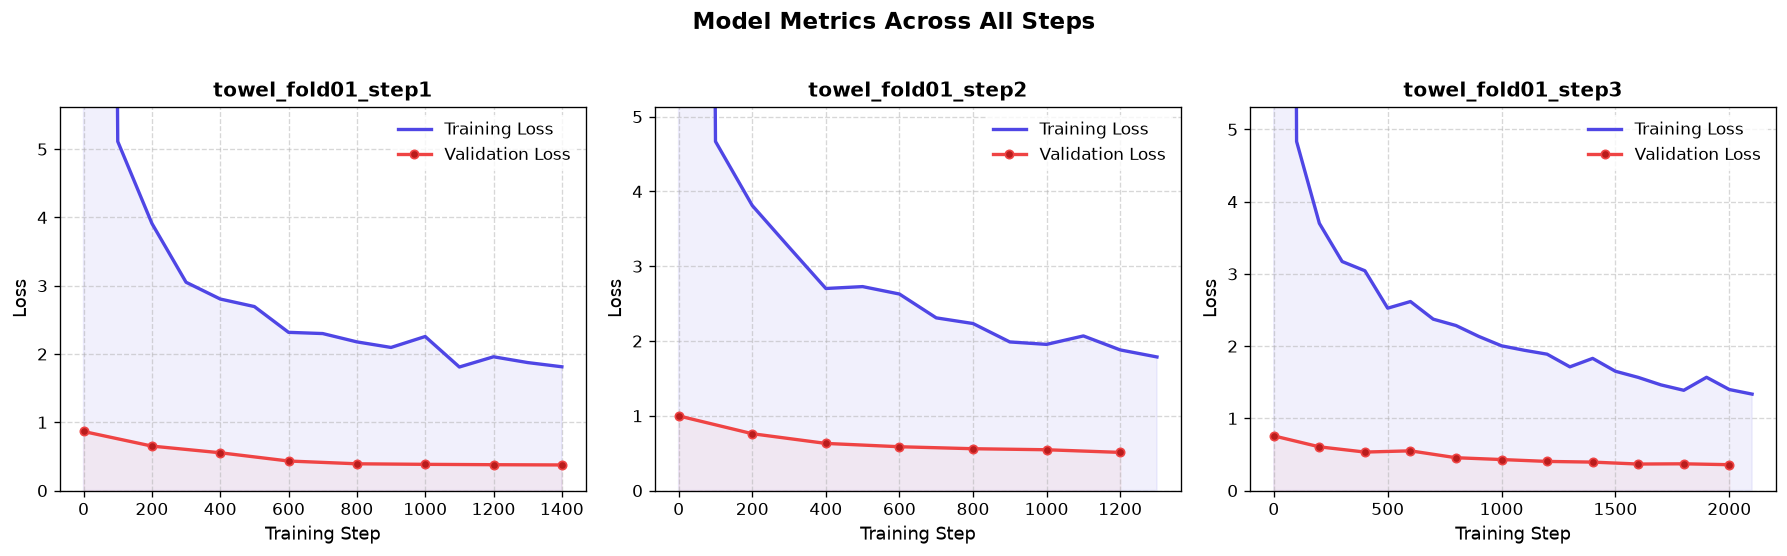

In [31]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Find all steps that have history
plots_data = []
for i, step_config in enumerate(steps):
    step_name = step_config.get("repo_id", f"step{i+1}").split("/")[-1]
    history_path = Path(f"../train/{clothing_name}_step{i+1}/loss_history.json")
    if history_path.exists():
        with open(history_path, "r") as f:
            history = json.load(f)
        plots_data.append((step_name, history))

if not plots_data:
    print("No loss history files found for any steps. Run training sessions first!")
else:
    num_plots = len(plots_data)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 4.5), dpi=120, squeeze=False)
    
    for idx, (step_name, history) in enumerate(plots_data):
        ax = axes[0, idx]
        
        train_steps = [entry["step"] for entry in history]
        train_losses = [entry["loss"] for entry in history]
        
        val_steps = [entry["step"] for entry in history if "val_loss" in entry]
        val_losses = [entry["val_loss"] for entry in history if "val_loss" in entry]
        
        # Plot Training Loss
        ax.plot(train_steps, train_losses, label="Training Loss", color="#4f46e5", linewidth=2)
        ax.fill_between(train_steps, train_losses, color="#4f46e5", alpha=0.08)
        
        # Plot Validation Loss
        if val_losses:
            ax.plot(
                val_steps, 
                val_losses, 
                label="Validation Loss", 
                color="#ef4444", 
                linewidth=2, 
                marker='o', 
                markersize=5, 
                markerfacecolor="#b91c1c"
            )
            ax.fill_between(val_steps, val_losses, color="#ef4444", alpha=0.05)
        
        ax.set_xlabel("Training Step", fontsize=11)
        ax.set_ylabel("Loss", fontsize=11)
        ax.set_title(step_name, fontsize=12, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(frameon=True, facecolor="white", edgecolor="none")
        
        # Dynamically calculate y-limit to exclude step 0 spike if possible
        losses_to_fit = []
        if len(train_losses) > 1:
            losses_to_fit.extend(train_losses[1:])
        else:
            losses_to_fit.extend(train_losses)
            
        if len(val_losses) > 1:
            losses_to_fit.extend(val_losses[1:])
        else:
            losses_to_fit.extend(val_losses)
            
        if losses_to_fit:
            max_val = max(losses_to_fit)
            ax.set_ylim(0, max_val * 1.1)
        else:
            ax.set_ylim(0, 1.0)
            
    plt.suptitle("Model Metrics Across All Steps", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


## 배포!

In [29]:
from lerobot.configs import PreTrainedConfig
from rollout import rollout
from pathlib import Path

i = 1
step_config = steps[i]
pretrained_path = Path(f"../train/{clothing_name}_step{i+1}") / "checkpoints" / "last"
policy_config = PreTrainedConfig.from_pretrained(pretrained_path, local_files_only=True)
policy_config.pretrained_path = pretrained_path
policies = [policy_config]
rollout_tasks = step_config["task"]

rollout(robot, policies, rollout_tasks, 20.0, asynchronous=False, compile=False)

WARNING 2026-07-09 16:54:55 a_opencv.py:285 OpenCVCamera(/dev/lerobot/camera_1) failed to set capture_width=160 (actual_width=640, width_success=True). Falling back to software resizing.
WARNING 2026-07-09 16:54:55 a_opencv.py:293 OpenCVCamera(/dev/lerobot/camera_1) failed to set capture_height=120 (actual_height=360, height_success=True). Falling back to software resizing.
INFO 2026-07-09 16:54:56 a_opencv.py:179 OpenCVCamera(/dev/lerobot/camera_1) connected.
INFO 2026-07-09 16:54:57 a_opencv.py:179 OpenCVCamera(/dev/lerobot/camera_0) connected.
INFO 2026-07-09 16:54:57 follower.py:105 lhwdev_follower_bimanual_left SOFollower connected.
WARNING 2026-07-09 16:54:58 a_opencv.py:285 OpenCVCamera(/dev/lerobot/camera_2) failed to set capture_width=160 (actual_width=640, width_success=True). Falling back to software resizing.
WARNING 2026-07-09 16:54:58 a_opencv.py:293 OpenCVCamera(/dev/lerobot/camera_2) failed to set capture_height=120 (actual_height=360, height_success=True). Falling back

=== Running Policy Step 0: R ===


INFO 2026-07-09 16:54:59 /context.py:209 Policy loaded: type=act, device=cuda
INFO 2026-07-09 16:54:59 /context.py:239 Reusing existing robot instance: bi_so_follower
INFO 2026-07-09 16:54:59 /context.py:248 Robot bi_so_follower is already connected, skipping connect.
INFO 2026-07-09 16:54:59 /context.py:253 Captured initial robot position (12 keys)
INFO 2026-07-09 16:54:59 /context.py:417 Creating inference engine (type=sync)...
INFO 2026-07-09 16:54:59 /factory.py:100 Creating inference engine: sync
INFO 2026-07-09 16:54:59 ence/sync.py:76 SyncInferenceEngine initialized (device=cuda, action_keys=12)
INFO 2026-07-09 16:54:59 /context.py:440 Rollout context assembled successfully
INFO 2026-07-09 16:54:59 gies/core.py:65 Starting inference engine...
INFO 2026-07-09 16:54:59 ence/sync.py:92 Resetting sync inference state (policy + processors)
INFO 2026-07-09 16:54:59 ence/sync.py:84 SyncInferenceEngine started (inline mode — no background thread)
INFO 2026-07-09 16:54:59 gies/core.py:70

Loading weights from local directory


WARNING 2026-07-09 16:54:59 g/rollout.py:87 Record loop is running slower (15.7 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:00 g/rollout.py:87 Record loop is running slower (30.1 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:01 g/rollout.py:87 Record loop is running slower (33.3 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:02 g/rollout.py:87 Record loop is running slower (37.5 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:02 g/rollout.py:87 Record loop is running slower (38.0 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:02 g/rollout.py:87 Record loop is running slower (37.7 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:02 g/rollout.py:87 Record loop is running slower (37.1 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:02 g/rollout.py:87 Record loop is running slower (39.1 Hz) than the target FPS (20.0 Hz).
WARNING 2026-07-09 16:55:03 g/rollout.py:87 Record loop is running slower (34.9 

Multi-step rollout finished. Disconnecting robot...


INFO 2026-07-09 16:55:26 a_opencv.py:609 OpenCVCamera(/dev/lerobot/camera_0) disconnected.
INFO 2026-07-09 16:55:26 follower.py:229 lhwdev_follower_bimanual_left SOFollower disconnected.
INFO 2026-07-09 16:55:26 a_opencv.py:609 OpenCVCamera(/dev/lerobot/camera_2) disconnected.
INFO 2026-07-09 16:55:26 follower.py:229 lhwdev_follower_bimanual_right SOFollower disconnected.


Done


In [ ]:
from lerobot.configs import PreTrainedConfig
from rollout import rollout
from pathlib import Path

policies = []
rollout_tasks = []
for i, step_config in enumerate(steps):
    pretrained_path = Path(f"../train/{clothing_name}_step{i+1}") / "checkpoints" / "last"
    policy_config = PreTrainedConfig.from_pretrained(pretrained_path, local_files_only=True)
    policy_config.pretrained_path = pretrained_path
    policies.append(policy_config)
    rollout_tasks.append(step_config["task"])

rollout(robot, policies, rollout_tasks, 20.0, asynchronous=False, compile=False)

In [ ]:
!lerobot-rollout \
    --strategy.type=base \
    --robot.type=bi_so_follower \
    --robot.id=lhwdev_follower3 \
    --robot.left_arm_config.port=/dev/lerobot/follower_1 \
    --robot.right_arm_config.port=/dev/lerobot/follower_2 \
    --robot.cameras='{top: {type: opencv, index_or_path: /dev/lerobot/camera_top, width: 640, height: 480, fps: 30}}' \
    --robot.left_arm_config.cameras='{cam: {type: opencv, index_or_path: /dev/lerobot/camera_1, width: 640, height: 480, fps: 30}}' \
    --robot.right_arm_config.cameras='{cam: {type: opencv, index_or_path: /dev/lerobot/camera_2, width: 640, height: 480, fps: 30}}' \
    --policy.path='./train/move_cube/checkpoints/last' \
    --task='Pick the blue cube, and put in red dish.' \
    --fps=10

In [ ]:
!lerobot-dataset-viz \
    --repo-id='lhwdev/cloth_folding_3_1' \
    --root='../records/cloth_folding_3_1' \
    --episode-index=5

INFO 2026-07-06 14:04:21 aset_viz.py:302 Loading dataset
INFO 2026-07-06 14:04:21 aset_viz.py:109 Loading dataloader
INFO 2026-07-06 14:04:21 aset_viz.py:116 Starting Rerun
2026-07-06T05:04:21.561620Z  INFO re_perf_telemetry::telemetry: Telemetry initialized enabled=false service=rerun trace_mode="off" traces=off logs=off metrics=off tracy=false
Error: winit EventLoopError: os error at /usr/local/cargo/registry/src/index.crates.io-1949cf8c6b5b557f/winit-0.30.13/src/platform_impl/linux/mod.rs:765: neither WAYLAND_DISPLAY nor WAYLAND_SOCKET nor DISPLAY is set.
^C


In [ ]:
!lerobot-replay \
    --robot.type=bi_so_follower \
    --robot.id=lhwdev_follower_bimanual \
    --robot.left_arm_config.port=/dev/lerobot/follower_1 \
    --robot.right_arm_config.port=/dev/lerobot/follower_2 \
    --dataset.repo_id='lhwdev/cloth_folding_3_1' \
    --dataset.root='../records/cloth_folding_3_1' \
    --dataset.episode=5 \
    --display_data=True \
    --control.fps=5

usage: lerobot-replay [-h] [--config_path str] [--robot str]
                      [--robot.type {openarm_follower,bi_openarm_follower,rebot_b601_follower,bi_rebot_b601_follower,so100_follower,so101_follower,bi_so_follower,earthrover_mini_plus,hope_jr_hand,hope_jr_arm,koch_follower,omx_follower,reachy2,unitree_g1}]
                      [--robot.can_interface str] [--robot.use_can_fd str]
                      [--robot.can_bitrate str] [--robot.can_data_bitrate str]
                      [--robot.use_velocity_and_torque str]
                      [--robot.motor_config str] [--robot.position_kp str]
                      [--robot.position_kd str]
                      [--robot.left_arm_config.side str]
                      [--robot.left_arm_config.can_interface str]
                      [--robot.left_arm_config.use_can_fd str]
                      [--robot.left_arm_config.can_bitrate str]
                      [--robot.left_arm_config.can_data_bitrate str]
                      [--ro

In [ ]:
!python ../../src/lerobot/scripts/control_robot.py \
    --robot.type=bi_so_follower \
    --robot.left_arm_config.port=/dev/lerobot/follower_1 \
    --robot.right_arm_config.port=/dev/lerobot/follower_2 \
    --robot.id=lhwdev_follower3 \
    --control.fps=30 \
    --control.policy.path='train/pick_umbrella3'

python: can't open file '/home/lhwdev/csi-agent/lerobot/lhwdev/../scripts/control_robot.py': [Errno 2] No such file or directory


In [ ]:
!lerobot-train \
    --dataset.repo_id='lhwdev/move_cube' \
    --dataset.root='/home/lhwdev/csi-agent/lerobot/lhwdev/records/move_cube' \
    --output_dir='train/move_cube_smolvla' \
    --policy.path=lerobot/smolvla_base \
    --policy.device=xpu \
    --policy.push_to_hub=false \
    --policy.output_features=null \
    --policy.input_features=null \
    --policy.optimizer_lr=1e-3 \
    --policy.scheduler_decay_lr=1e-4 \
    --peft.method_type=LORA \
    --peft.r=64 \
    --steps=100 \
    --batch_size=32

/bin/bash: /home/lhwdev/miniconda3/envs/lerobot/lib/libtinfo.so.6: no version information available (required by /bin/bash)
INFO 2026-06-26 17:15:09 ot_train.py:221 {'batch_size': 32,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataset': {'episodes': None,
             'image_transforms': {'enable': False,
                                  'max_num_transforms': 3,
                                  'random_order': False,
                                  'tfs': {'affine': {'kwargs': {'degrees': [-5.0,
                                                                            5.0],
                                                                'translate': [0.05,
                                                                              0.05]},
                                                     'type': 'RandomAffine',
                                                     'weight': 1.0},
                                          'brightness': {'kwargs': {'brightness':

In [ ]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from pathlib import Path

existing_episodes = list(range(12)) + list(range(16, 41))

try:
    dataset = LeRobotDataset(
        "lhwdev/cloth_folding_3",
        root=str(Path("../records/cloth_folding_3").resolve()),
        episodes=existing_episodes,
    )
    print("Successfully loaded dataset!")
    print(f"Loaded episodes: {dataset.episodes}")
except Exception as e:
    import traceback
    traceback.print_exc()


Traceback (most recent call last):
  File "/tmp/ipykernel_8134/2485957569.py", line 7, in <module>
    dataset = LeRobotDataset(
              ^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/datasets/lerobot_dataset.py", line 253, in __init__
    if force_cache_sync or not self.reader.try_load():
                               ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/datasets/dataset_reader.py", line 108, in try_load
    if not self._check_cached_episodes_sufficient():
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/datasets/dataset_reader.py", line 166, in _check_cached_episodes_sufficient
    video_path = self.root / self._meta.get_video_file_path(ep_idx, vid_key)
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lerobot/lerobot2/csi-agent/lerobot/src/lerobot/datasets/dataset_metadata.py", line 297, in get_vi